In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


NumPy for numerical computations ,Pandas was used for data manipulation, Matplotlib for creating graphical representations, and Seaborn for generating advanced statistical visualizations. These libraries provide the foundation for preprocessing, analyzing, and interpreting the dataset effectively.


SimpleImputer and KNNImputer were used to address missing data through statistical and machine learning-based techniques. The zscore function was utilized to detect outliers, while winsorize was applied to limit the effect of extreme values. These preprocessing steps improve data quality, enhance model performance, and ensure reliable analytical results.

In [183]:
df = pd.read_csv("/content/RealEstate_HousePrice_Dataset_4200 - RealEstate_HousePrice_Dataset_4200.csv.csv")


The dataset was loaded into a Pandas DataFrame to enable data analysis, preprocessing, and visualization.



In [184]:
df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


The first few records were examined to understand the structure of the dataset and identify the available features.





In [185]:
df.tail()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
4195,104196,1328,4,2,4.9,21,19.6,2606,1,0,21,18319188
4196,104197,2363,6,4,6.9,53,24.9,4013,1,0,14,40340976
4197,104198,632,2,2,4.5,27,19.4,1268,1,0,6,5978595
4198,104199,450,2,2,7.5,26,11.6,800,0,0,9,7916191
4199,104200,2021,4,3,6.8,25,12.5,2351,1,1,4,34319843


In [186]:
df.shape

(4200, 12)

The total number of rows and columns was identified to understand the size and dimensionality of the dataset.

In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB


The dataset information was examined to understand the data types, identify missing values, and estimate memory usage.

In [188]:
df.columns

Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score',
       'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage',
       'has_pool', 'renovation_years_ago', 'house_price_inr'],
      dtype='object')

In [189]:
df.isnull().sum()

,0
house_id,0
area_sqft,0
bedrooms,0
bathrooms,0
location_score,0
age_years,0
distance_city_km,0
lot_size_sqft,0
has_garage,0
has_pool,0


lays the number of missing (null) values present in each column of the dataset.

In [190]:
df.duplicated().sum()

np.int64(0)

This code is used to check sum of duplicate .

Duplicate records were checked to ensure data quality. Removing duplicate entries helps prevent biased model training.

In [191]:
X = df.drop("house_price_inr", axis=1)

y = df["house_price_inr"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (4200, 11)
Target Shape : (4200,)


This code used to check seprate the Feature shape and target shape.

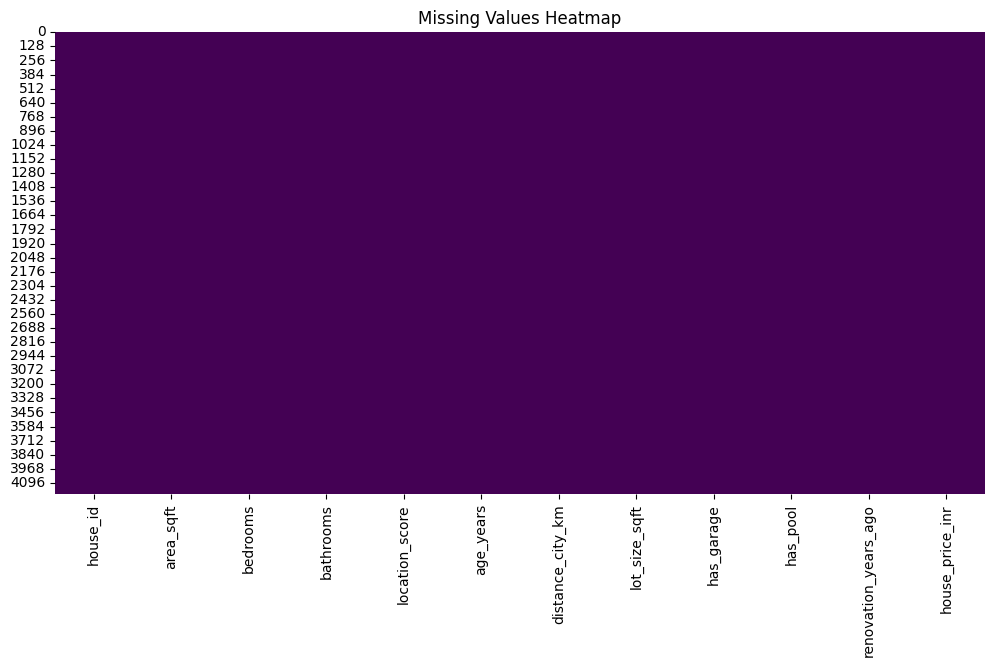

In [280]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")

plt.show()

The heatmap visually highlights missing values in the dataset. Yellow/light areas indicate missing values, while dark areas indicate available data.

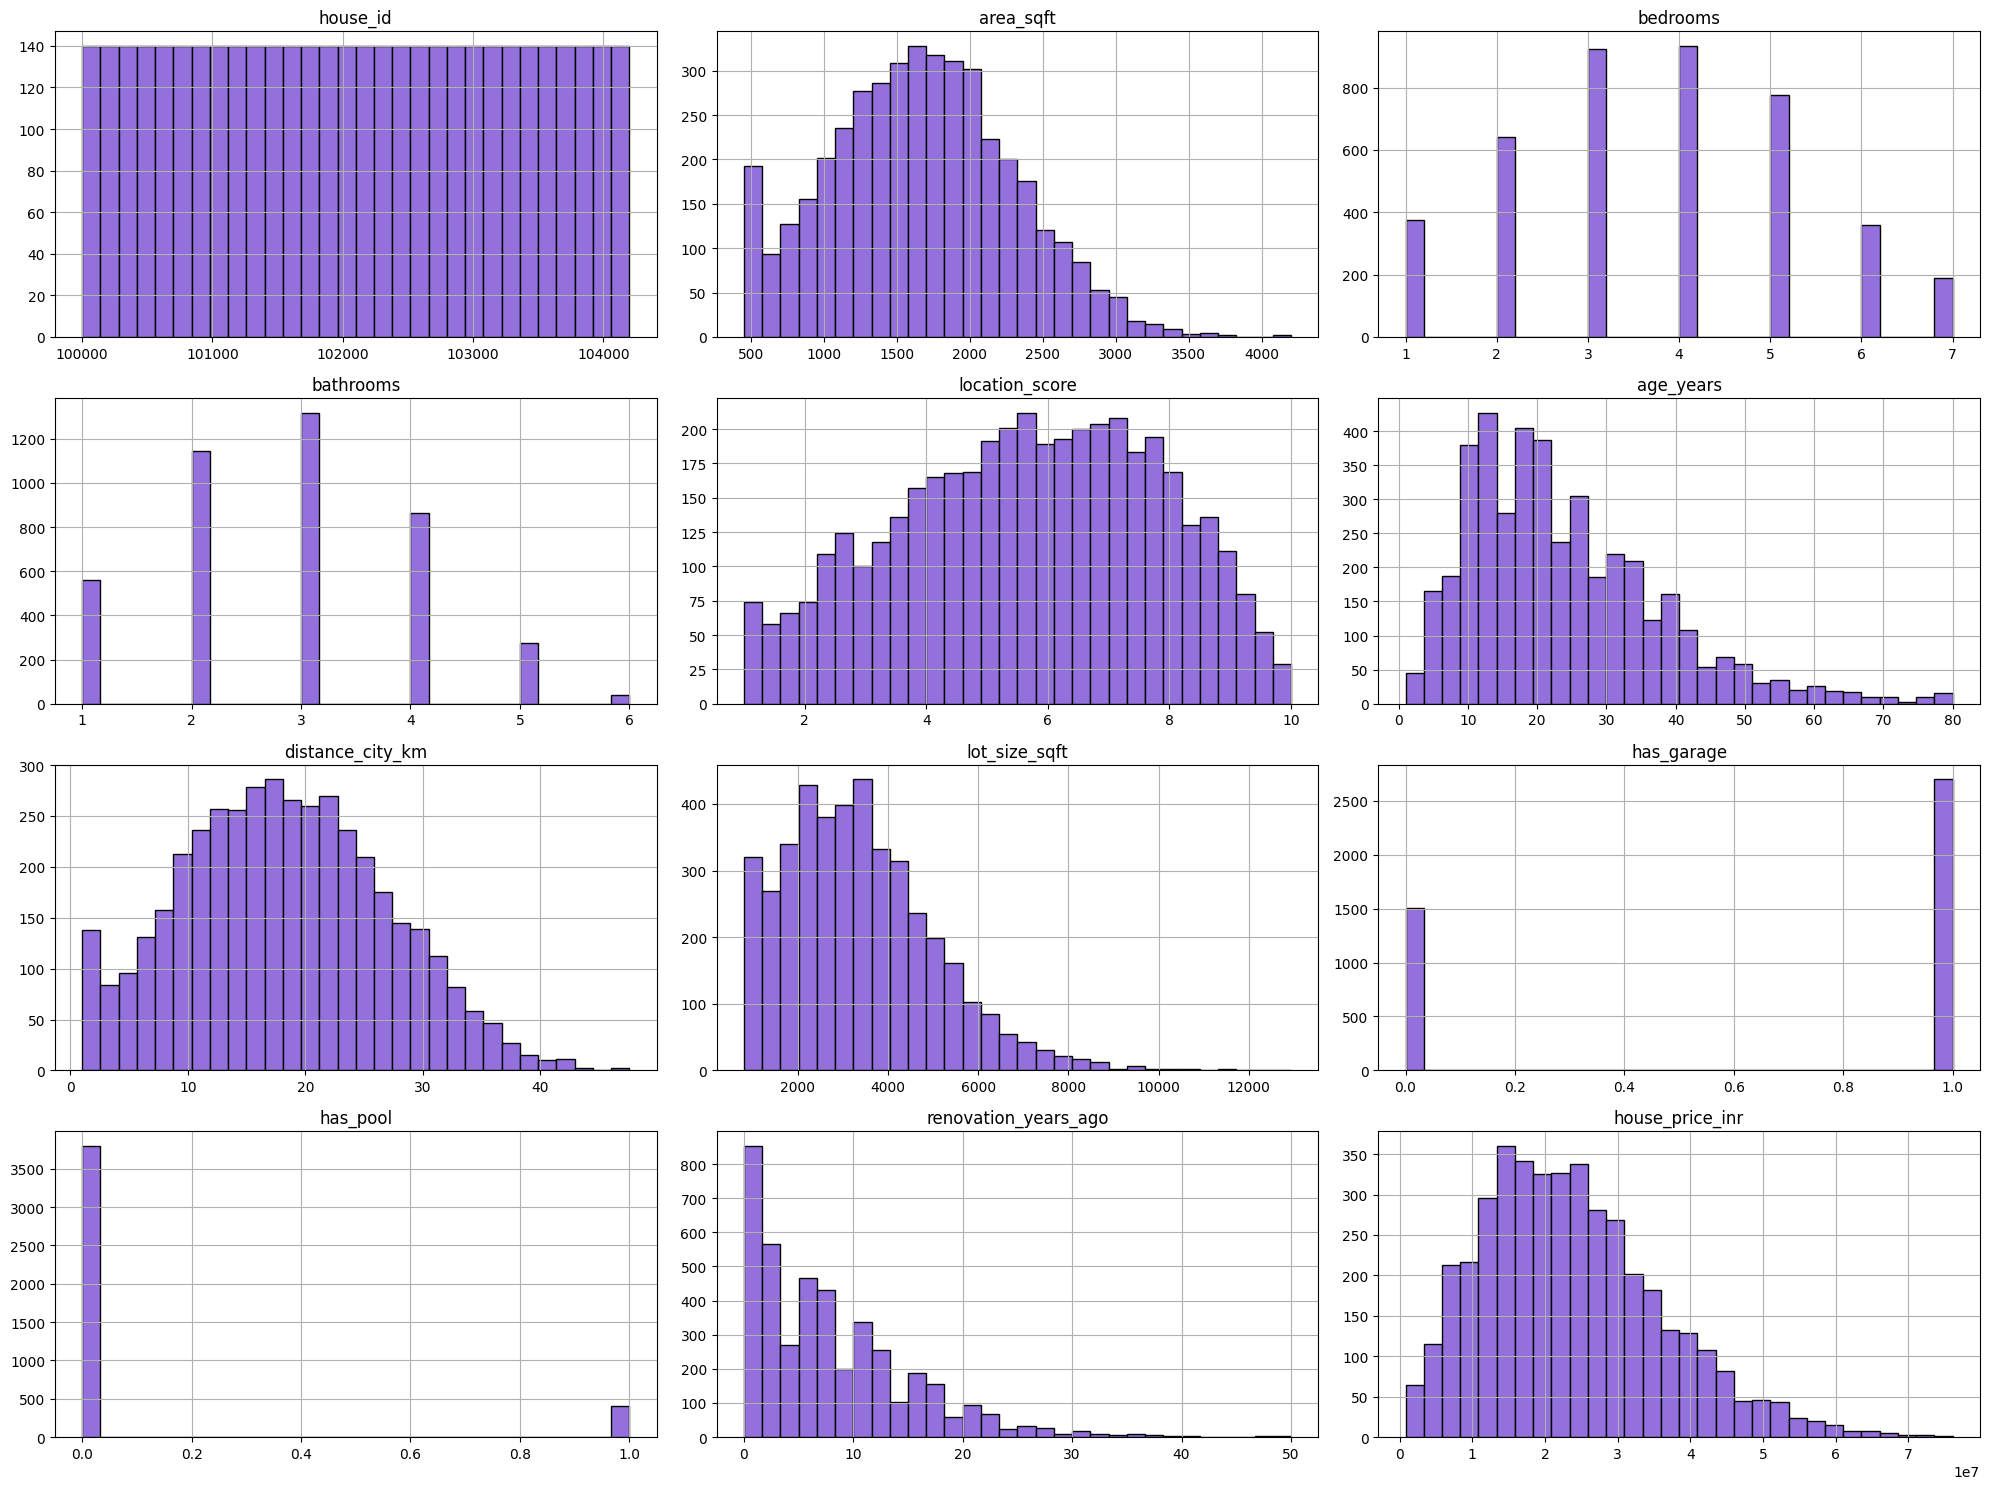

In [192]:
import matplotlib.pyplot as plt

df.hist(
    figsize=(20, 15),
    bins=30,
    color='mediumpurple',
    edgecolor='black'
)

plt.tight_layout()
plt.show()

This code generates histograms for all numerical columns in the dataset. The histograms help understand the distribution, frequency, spread, and possible outliers of each feature before building the machine learning model.

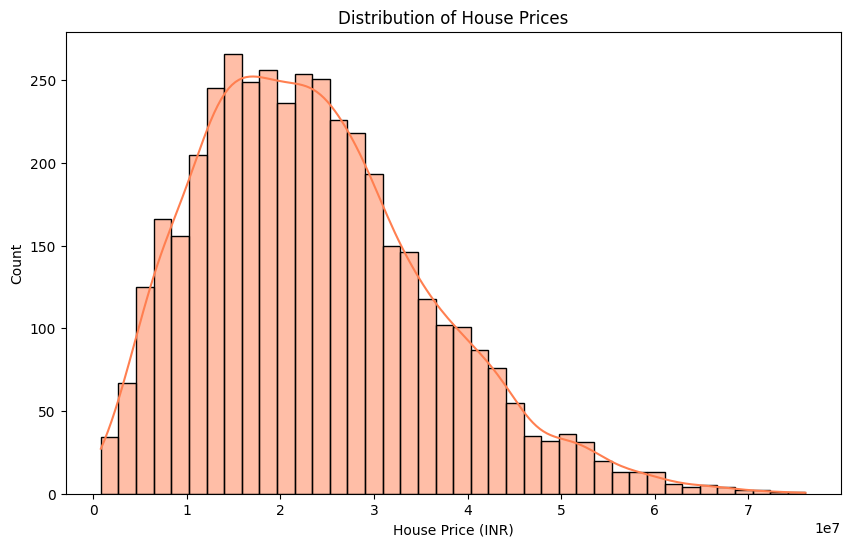

In [193]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["house_price_inr"],
    bins=40,
    kde=True,
    color="coral"
)

plt.title("Distribution of House Prices")
plt.xlabel("House Price (INR)")
plt.ylabel("Count")

plt.show()

This visualization provides valuable insights into the distribution of house prices in the dataset. It helps identify common price ranges, detect skewness or outliers, and assess whether the target variable follows a normal distribution. These insights are useful for selecting appropriate preprocessing techniques and improving the performance of the house price prediction model.

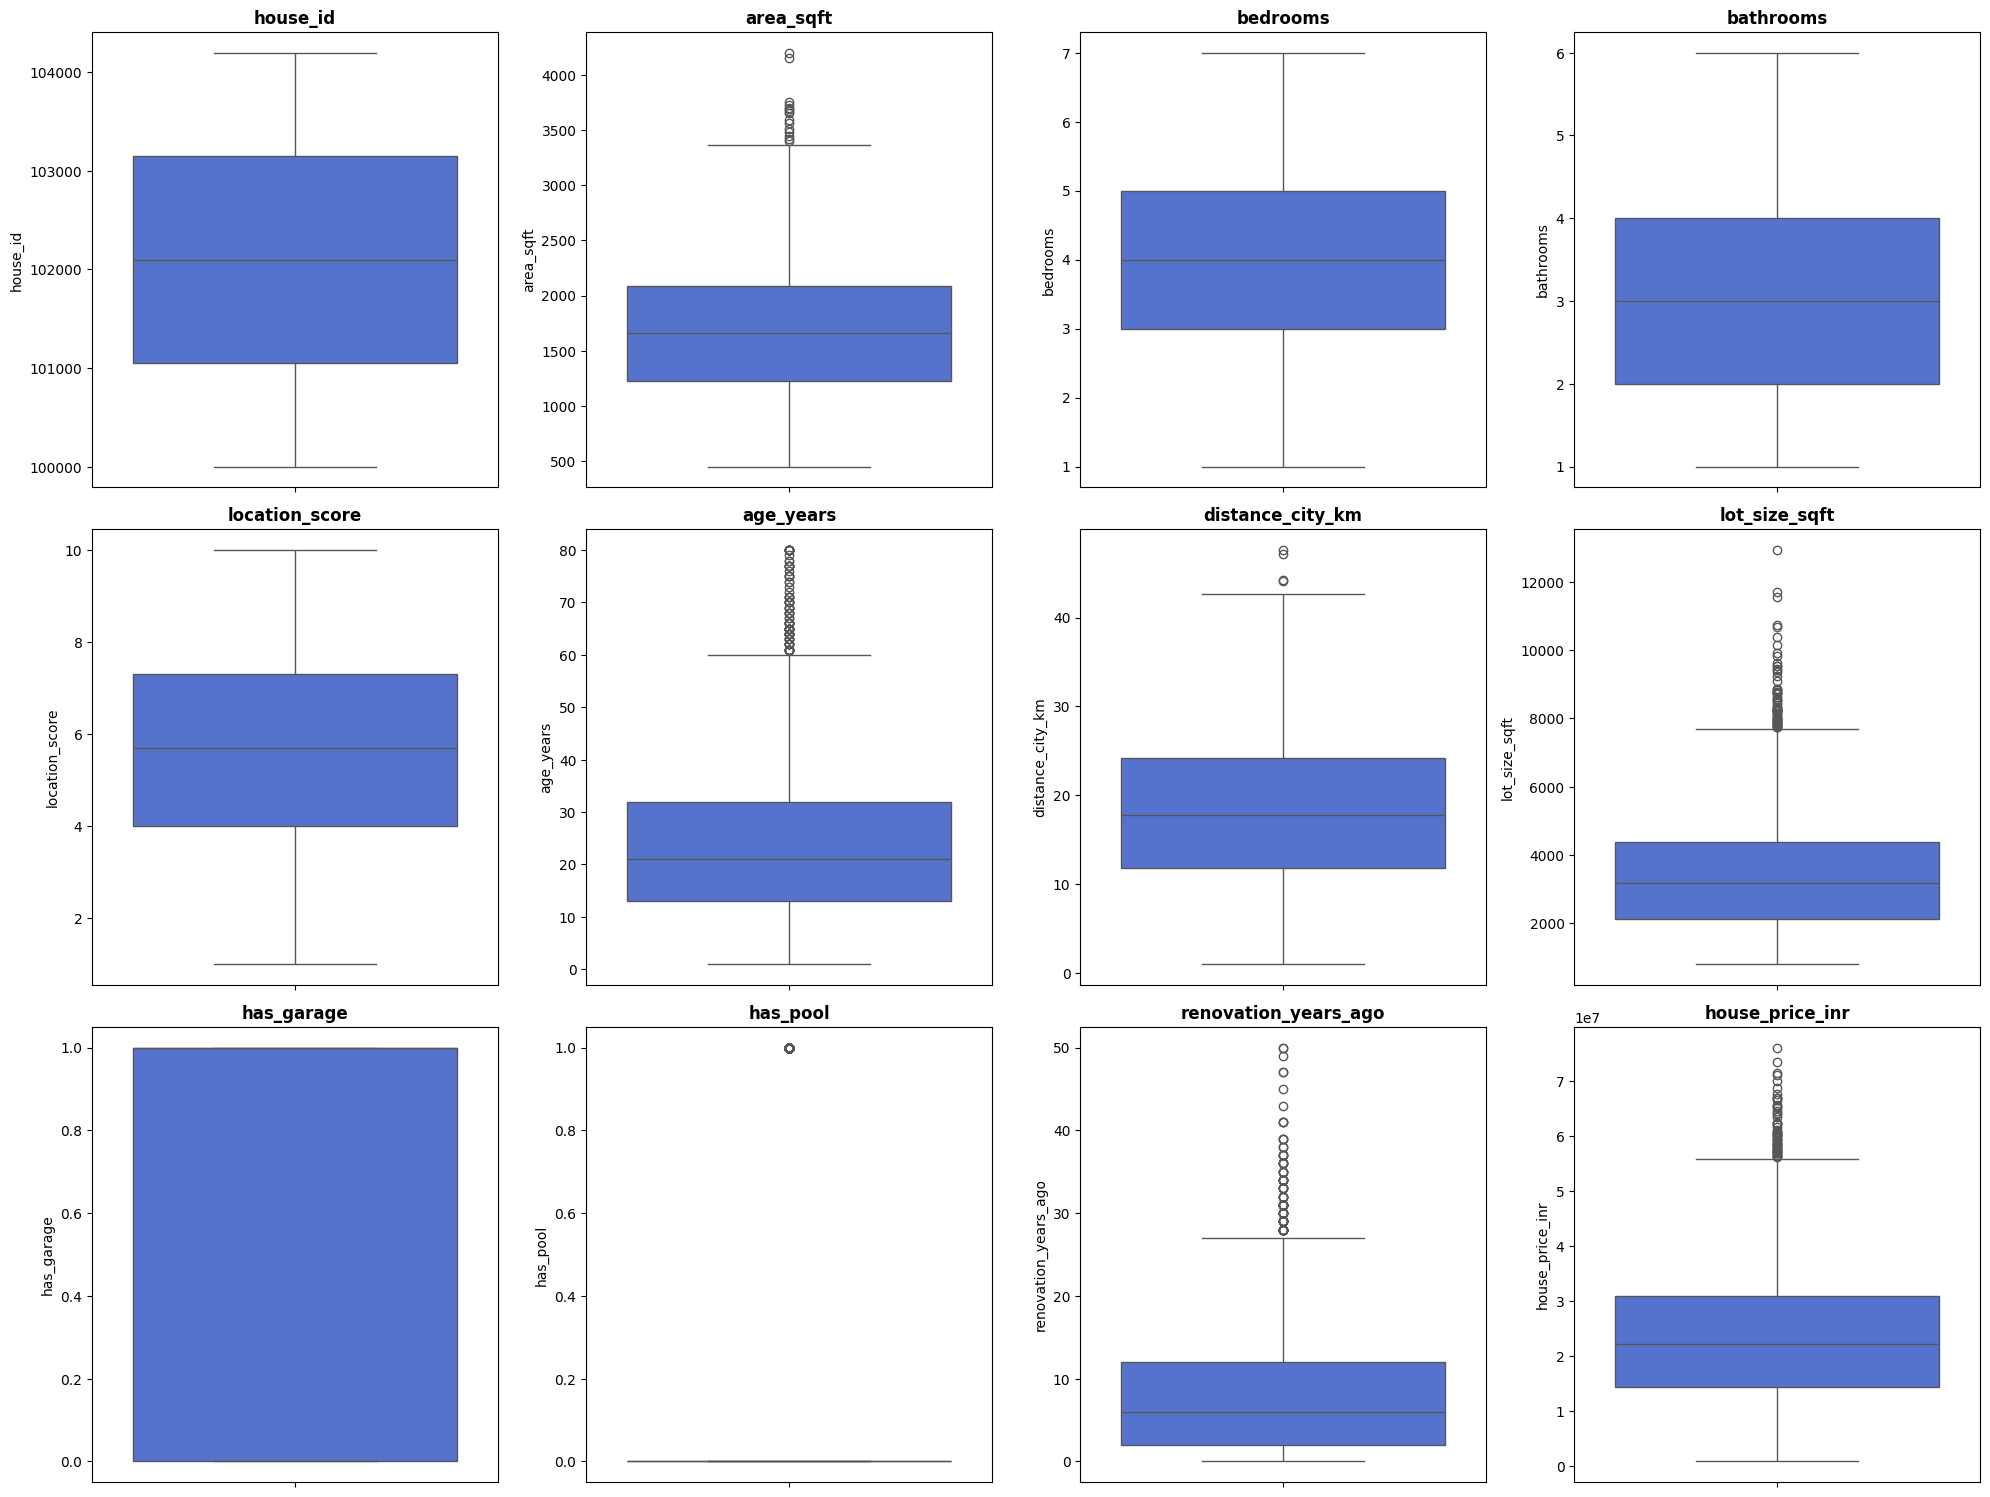

In [194]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numerical_columns = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(20,20))

for i, column in enumerate(numerical_columns):

    plt.subplot(4,4,i+1)

    sns.boxplot(
        y=df[column],
        color="royalblue"
    )

    plt.title(column, fontsize=12, fontweight="bold")

plt.tight_layout()

plt.show()

This code creates boxplots for all numerical columns in the dataset. The boxplots help visualize the distribution, median, spread, and potential outliers of each feature, allowing better understanding of the data before model development.

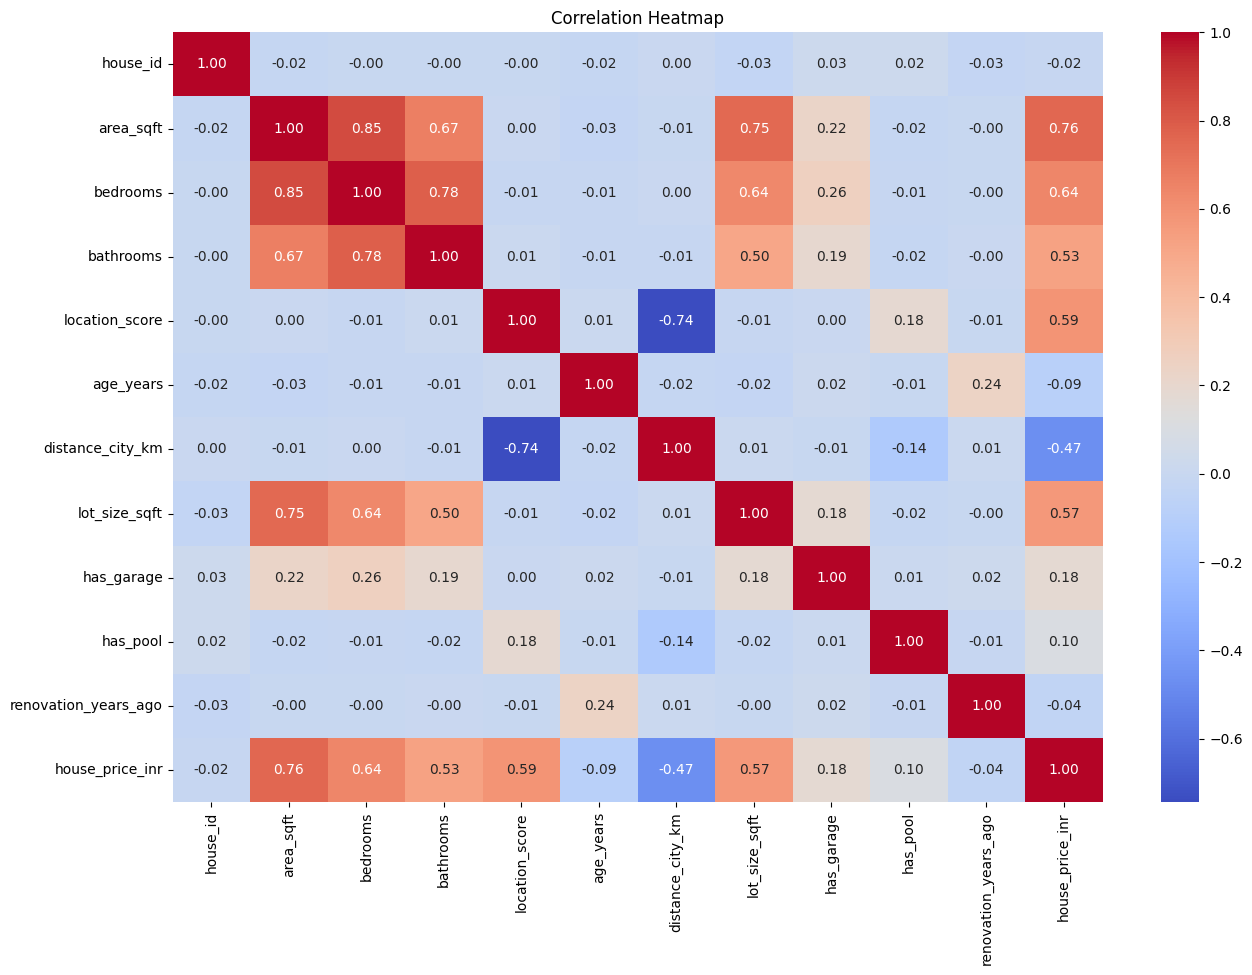

In [195]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

This code calculates the correlation between all numerical features in the dataset and displays the results as a heatmap. The correlation matrix measures the strength and direction of the relationship between pairs of variables, with values ranging from -1 to +1. Positive values indicate that two variables increase together, while negative values indicate an inverse relationship. The heatmap uses different colors to represent the correlation strength, making it easier to identify highly related features, potential multicollinearity, and the variables that have the strongest relationship with the target variable (house_price_inr). This analysis helps in feature selection and improves the understanding of the dataset before building machine learning models.

In [196]:
correlation = corr["house_price_inr"].sort_values(ascending=False)

print(correlation)

house_price_inr         1.000000
area_sqft               0.755434
bedrooms                0.644772
location_score          0.588531
lot_size_sqft           0.567751
bathrooms               0.527044
has_garage              0.176934
has_pool                0.102015
house_id               -0.015115
renovation_years_ago   -0.037409
age_years              -0.089454
distance_city_km       -0.469431
Name: house_price_inr, dtype: float64


This code extracts the correlation values between the target variable (house_price_inr) and all other numerical features in the dataset. The correlation values are then sorted in descending order, allowing the features with the strongest positive relationship to appear first. Printing this sorted list makes it easy to identify which variables have the greatest influence on house prices and which have little or negative impact. This analysis is valuable for feature selection, as highly correlated features are generally more useful for building accurate machine learning models.

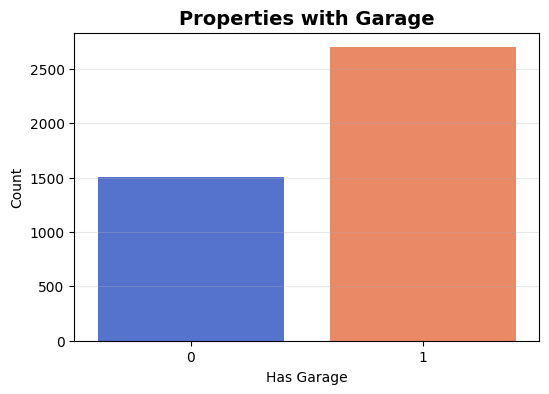

In [197]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x="has_garage",
    data=df,
    hue="has_garage",
    palette=["royalblue", "coral"],
    legend=False
)

plt.title("Properties with Garage", fontsize=14, fontweight="bold")
plt.xlabel("Has Garage")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.show()

This code creates a count plot for the has_garage feature to show the number of properties with and without a garage. It helps analyze the distribution of this categorical variable and understand its potential impact on house prices.

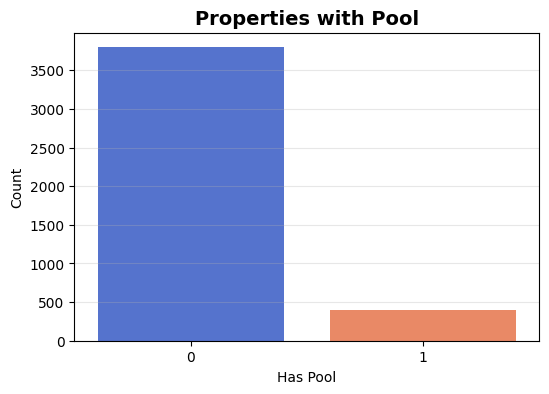

In [198]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x="has_pool",
    data=df,
    hue="has_pool",
    palette=["royalblue", "coral"],
    legend=False
)

plt.title("Properties with Pool", fontsize=14, fontweight="bold")
plt.xlabel("Has Pool")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.show()

This code generates a count plot for the has_pool feature to compare the number of properties with and without a swimming pool. It helps understand the distribution of this categorical feature during exploratory data analysis (EDA).

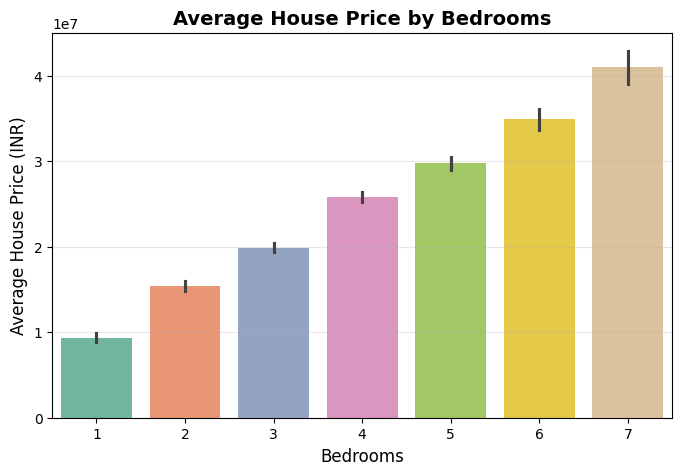

In [199]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="bedrooms",
    y="house_price_inr",
    hue="bedrooms",
    palette="Set2",
    legend=False
)

plt.title("Average House Price by Bedrooms", fontsize=14, fontweight="bold")
plt.xlabel("Bedrooms", fontsize=12)
plt.ylabel("Average House Price (INR)", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.show()

This code creates a bar plot to compare the average house price for properties with different numbers of bedrooms. Each bar represents the mean house price for a specific bedroom category, allowing an easy comparison of how property prices vary as the number of bedrooms increases. Different colors are used to distinguish each bedroom category, making the chart more visually appealing. This analysis helps determine whether the number of bedrooms has a significant impact on house prices and provides valuable insights for feature selection in the predictive model.

In [200]:
print("Missing Values in Each Column:\n")
print(df.isnull().sum())

Missing Values in Each Column:

house_id                0
area_sqft               0
bedrooms                0
bathrooms               0
location_score          0
age_years               0
distance_city_km        0
lot_size_sqft           0
has_garage              0
has_pool                0
renovation_years_ago    0
house_price_inr         0
dtype: int64


This code checks for missing values in every column of the dataset and displays the total count of null values. It helps identify incomplete data that may require preprocessing before model development.

In [201]:
binary_columns = []

df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


This code creates an empty list to store binary feature names and displays the first five rows of the dataset. It helps inspect the data and identify columns that contain binary values (0 and 1).

In [202]:
X = df.drop("house_price_inr", axis=1)

y = df["house_price_inr"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (4200, 11)
Target Shape : (4200,)


This code separates the dataset into input features (X) and the target variable (y). The feature matrix contains all independent variables, while the target vector contains the house prices to be predicted. The shapes of both are printed to verify the data preparation.

In [203]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)


Training Features : (3360, 11)
Testing Features  : (840, 11)
Training Target   : (3360,)
Testing Target    : (840,)


This code divides the dataset into training and testing sets using an 80:20 ratio. The training data is used to build the machine learning model, while the testing data is used to evaluate its prediction performance. The shapes of the resulting datasets are displayed for verification.

In [204]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


This code standardizes the input features using StandardScaler. The scaler is fitted on the training data and then applied to both the training and testing datasets. Feature scaling improves model performance by ensuring all variables are measured on the same scale.

In [205]:
scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

scaled_df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago
0,0.243947,0.318682,1.461879,1.014250,0.390660,-1.278977,-1.001581,0.891910,0.745839,-0.328906,-1.085032
1,1.412675,0.470115,0.190351,0.151277,0.949023,-0.628999,-0.623039,0.581727,0.745839,-0.328906,0.975078
2,-1.561363,0.843963,0.826115,0.151277,-1.470550,-0.412340,0.420821,1.078020,-1.340772,-0.328906,-0.260988
3,1.251871,0.733544,0.826115,1.014250,-0.912187,1.248713,0.363466,0.156417,0.745839,-0.328906,-0.260988
4,-0.480498,-0.498421,-1.081177,0.151277,0.018418,-0.556780,0.845248,-0.475879,0.745839,-0.328906,1.112419


This step converts the standardized training data into a well-structured DataFrame with the original feature names, making the scaled data easier to inspect and interpret. Displaying the first five rows confirms that feature scaling has been successfully applied and that the dataset is properly formatted for machine learning model training

In [206]:
from sklearn.linear_model import Ridge

In [207]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

Ridge()

This code initializes a Ridge Regression model with a regularization parameter of 1.0 and trains it using the standardized training dataset. Ridge Regression helps reduce overfitting and improves the model's ability to generalize to unseen data.

In [208]:
ridge_train_pred = ridge_model.predict(X_train_scaled)

ridge_test_pred = ridge_model.predict(X_test_scaled)

This code generates predicted house prices for both the training and testing datasets using the trained Ridge Regression model. These predictions are used to evaluate the model's accuracy and overall performance.

In [209]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

ridge_mae = mean_absolute_error(y_test, ridge_test_pred)

ridge_mse = mean_squared_error(y_test, ridge_test_pred)

ridge_rmse = np.sqrt(ridge_mse)

ridge_r2 = r2_score(y_test, ridge_test_pred)

This code evaluates the performance of the Ridge Regression model by calculating four widely used regression evaluation metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. These metrics compare the actual house prices with the predicted values to measure the model's prediction accuracy. Lower values of MAE, MSE, and RMSE indicate fewer prediction errors, while an R² Score closer to 1 indicates that the model explains a larger proportion of the variation in house prices. Together, these metrics provide a comprehensive assessment of the model's performance.

In [210]:
train_score = ridge_model.score(X_train_scaled, y_train)

test_score = ridge_model.score(X_test_scaled, y_test)

This code calculates the R² score (coefficient of determination) of the trained Ridge Regression model on both the training and testing datasets. The training score measures how well the model has learned the patterns from the training data, while the testing score evaluates how effectively the model predicts house prices for new, unseen data. Comparing these two scores helps determine whether the model is well-generalized, overfitting, or underfitting. Ideally, both scores should be high and close to each other, indicating that the model performs consistently on both known and unseen data.

In [211]:
ridge_coefficients = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": ridge_model.coef_

})

ridge_coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
1,area_sqft,8.733057e+06
4,location_score,6.600598e+06
2,bedrooms,3.188119e+05
3,bathrooms,2.158568e+05
7,lot_size_sqft,1.773407e+05
9,has_pool,1.355873e+05
8,has_garage,4.554486e+04
0,house_id,-1.444260e+04
10,renovation_years_ago,-1.563873e+05
6,distance_city_km,-8.656709e+05


This code extracts the feature coefficients learned by the trained Ridge Regression model and organizes them into a structured table. Each coefficient represents the influence of a feature on the predicted house price. A positive coefficient indicates that an increase in the feature value tends to increase the predicted house price, while a negative coefficient suggests that an increase in the feature value tends to decrease the predicted house price. Finally, the coefficients are sorted in descending order, making it easy to identify the most influential features in the model.

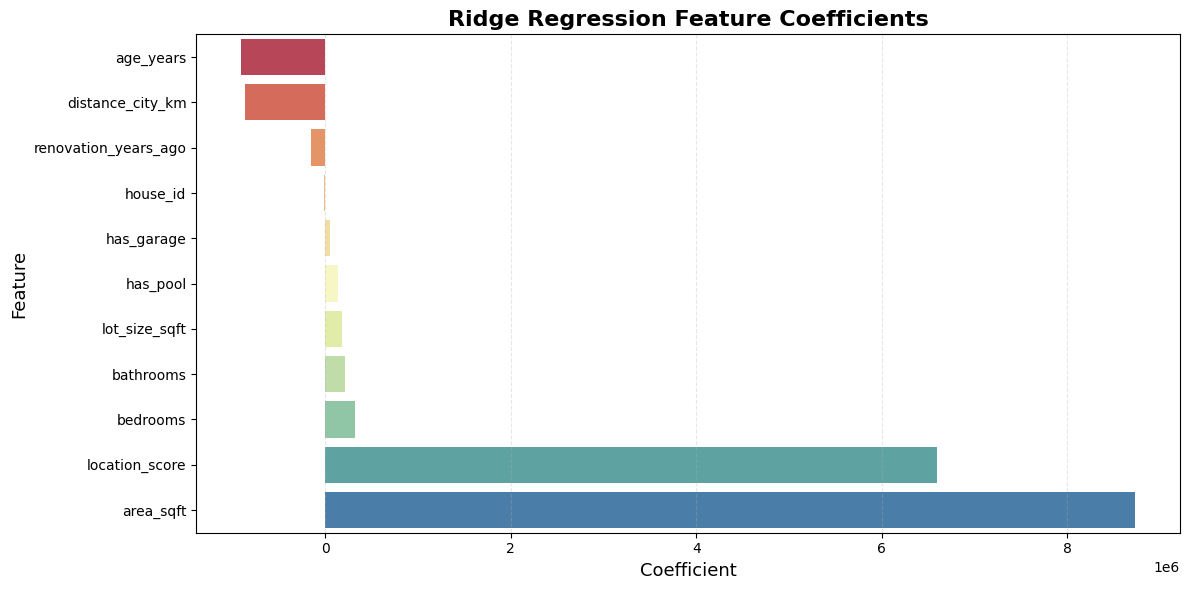

In [212]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=ridge_coefficients.sort_values("Coefficient"),
    x="Coefficient",
    y="Feature",
    hue="Feature",
    palette="Spectral",
    legend=False
)

plt.title("Ridge Regression Feature Coefficients", fontsize=16, fontweight="bold")
plt.xlabel("Coefficient", fontsize=13)
plt.ylabel("Feature", fontsize=13)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

This code creates a horizontal bar chart to visualize the coefficients of the trained Ridge Regression model. Each bar represents the importance and direction of a feature's contribution to house price prediction. Features with positive coefficients increase the predicted house price, while features with negative coefficients decrease it. The coefficients are sorted in ascending order so that the least influential negative features appear at the bottom and the strongest positive features appear at the top. This visualization makes it easier to identify the most significant factors affecting house prices and improves the interpretability of the machine learning model.

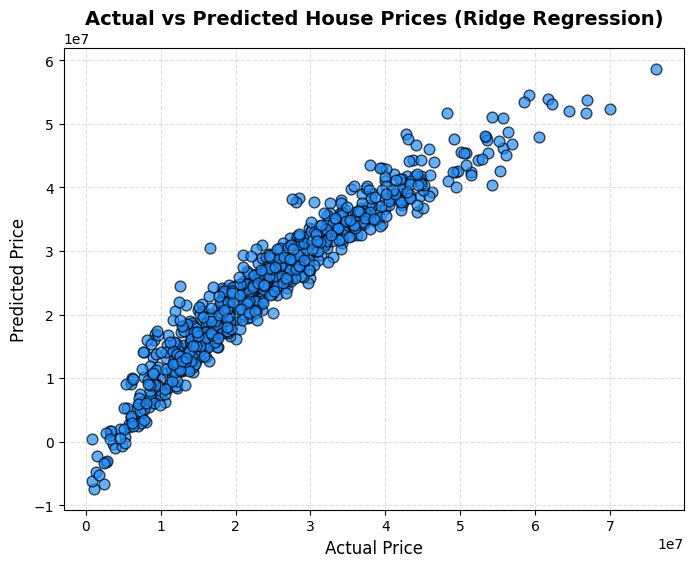

In [213]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    ridge_test_pred,
    color="dodgerblue",
    edgecolors="black",
    alpha=0.7,
    s=60
)

plt.xlabel("Actual Price", fontsize=12)
plt.ylabel("Predicted Price", fontsize=12)
plt.title("Actual vs Predicted House Prices (Ridge Regression)", fontsize=14, fontweight="bold")

plt.grid(True, linestyle="--", alpha=0.4)

plt.show()


This scatter plot visually evaluates the performance of the Ridge Regression model by comparing actual and predicted house prices. A strong concentration of points near the imaginary diagonal line indicates high prediction accuracy and good model generalization. Any points that lie far from this line highlight prediction errors or outliers, making this visualization an effective tool for assessing the reliability and overall performance of the house price prediction model.

In [214]:
from sklearn.linear_model import Lasso


In [215]:
lasso_model = Lasso(alpha=1.0) # Initialize the Lasso model

lasso_model.fit(X_train_scaled, y_train) # Fit the Lasso model

lasso_train_pred = lasso_model.predict(X_train_scaled)

lasso_test_pred = lasso_model.predict(X_test_scaled)

This step initializes and trains the Lasso Regression model using the standardized training data and generates predictions for both the training and testing datasets. By applying L1 regularization, Lasso Regression reduces overfitting while automatically identifying the most important features for house price prediction. The generated predictions will be used in the next step to evaluate the model's performance using metrics such as MAE, MSE, RMSE, and R² Score.

In [216]:
lasso_mae = mean_absolute_error(y_test, lasso_test_pred)

lasso_mse = mean_squared_error(y_test, lasso_test_pred)

lasso_rmse = np.sqrt(lasso_mse)

lasso_r2 = r2_score(y_test, lasso_test_pred)

This code evaluates the performance of the Lasso Regression model by calculating four important regression evaluation metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. These metrics compare the actual house prices with the values predicted by the Lasso Regression model to determine its prediction accuracy. Lower values of MAE, MSE, and RMSE indicate smaller prediction errors, while an R² Score closer to 1 indicates that the model explains a larger proportion of the variation in house prices. These evaluation metrics are essential for assessing the effectiveness of the Lasso Regression model and comparing its performance with other models such as Ridge Regression.

In [217]:
lasso_train_score = lasso_model.score(X_train_scaled, y_train)

lasso_test_score = lasso_model.score(X_test_scaled, y_test)

This step evaluates the Lasso Regression model by calculating the R² scores for both the training and testing datasets. Comparing these scores helps assess whether the model has learned meaningful patterns without overfitting. A high and similar R² score on both datasets indicates that the model is reliable, generalizes well to unseen data, and is suitable for accurate house price prediction.

In [218]:
lasso_coefficients = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": lasso_model.coef_

})

lasso_coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
1,area_sqft,8.745282e+06
4,location_score,6.604535e+06
2,bedrooms,3.116036e+05
3,bathrooms,2.155355e+05
7,lot_size_sqft,1.729604e+05
9,has_pool,1.353469e+05
8,has_garage,4.555396e+04
0,house_id,-1.433019e+04
10,renovation_years_ago,-1.563537e+05
6,distance_city_km,-8.628894e+05


This code extracts the feature coefficients learned by the trained Lasso Regression model and stores them in a Pandas DataFrame. Each coefficient indicates the importance and direction of a feature's influence on house price prediction. Features with positive coefficients contribute to increasing the predicted house price, while negative coefficients contribute to decreasing it. One of the key characteristics of Lasso Regression is that it can assign a coefficient of zero to less important features, effectively removing them from the model. Finally, the coefficients are sorted in descending order to identify the most influential features.

/tmp/ipykernel_2397/1022040212.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


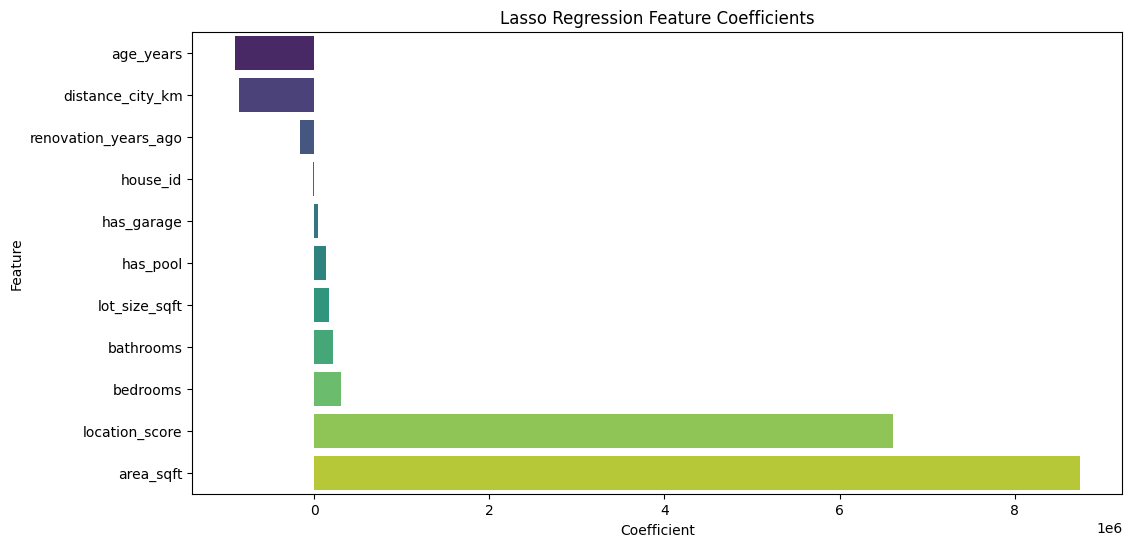

In [281]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=lasso_coefficients.sort_values("Coefficient"),
    x="Coefficient",
    y="Feature",
    palette="viridis"   # try: "magma", "plasma", "coolwarm"
)

plt.title("Lasso Regression Feature Coefficients")

plt.show()

This visualization provides a clear representation of the feature coefficients learned by the Lasso Regression model. By displaying the magnitude and direction of each coefficient, it helps identify the most influential variables affecting house prices. Additionally, it highlights Lasso Regression's ability to perform automatic feature selection by assigning zero coefficients to less important features, resulting in a simpler, more interpretable, and efficient predictive model.

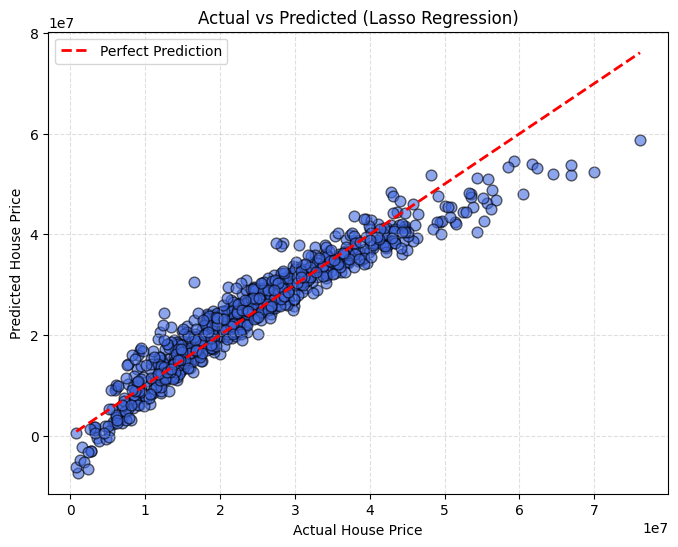

In [282]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    lasso_test_pred,
    alpha=0.6,
    color="royalblue",
    edgecolor="black",
    s=60
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted (Lasso Regression)")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

This code creates a scatter plot to compare the actual house prices with the house prices predicted by the Lasso Regression model. Each point on the graph represents one property from the testing dataset, where the x-axis shows the actual house price and the y-axis shows the predicted house price. If the model predicts accurately, most points will lie close to an imaginary 45-degree diagonal line, indicating that the predicted values closely match the actual values. This visualization helps assess the prediction accuracy of the Lasso Regression model and identify any outliers or large prediction errors.

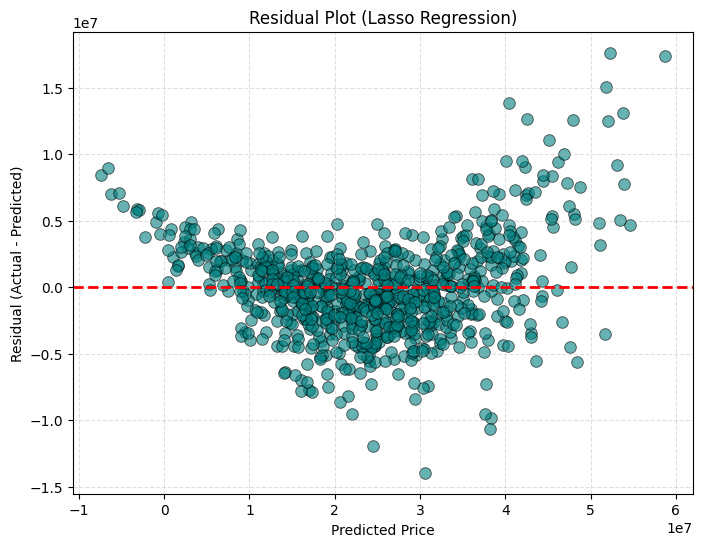

In [283]:
lasso_residuals = y_test - lasso_test_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=lasso_test_pred,
    y=lasso_residuals,
    color="teal",
    alpha=0.6,
    edgecolor="black",
    s=70
)

plt.axhline(0, color='red', linestyle='--', linewidth=2)

plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot (Lasso Regression)")

plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

This code calculates the residuals (prediction errors) of the Lasso Regression model and visualizes them using a residual scatter plot. A residual is the difference between the actual house price and the predicted house price. The plot displays the predicted house prices on the x-axis and the corresponding residuals on the y-axis. A horizontal reference line is drawn at zero residual, representing perfect predictions. If the residuals are randomly scattered around this line without any clear pattern, it indicates that the Lasso Regression model fits the data well. However, visible patterns or systematic trends may suggest that the model is missing important relationships or assumptions.

In [222]:
comparison = pd.DataFrame({

    "Model": ["Ridge Regression", "Lasso Regression"],

    "MAE": [ridge_mae, lasso_mae],

    "MSE": [ridge_mse, lasso_mse],

    "RMSE": [ridge_rmse, lasso_rmse],

    "R2 Score": [ridge_r2, lasso_r2]

})

comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Ridge Regression,2.605803e+06,1.260064e+13,3.549738e+06,0.917710
1,Lasso Regression,2.605649e+06,1.259722e+13,3.549257e+06,0.917733


This code creates a comparison table that summarizes the performance of the Ridge Regression and Lasso Regression models using four important evaluation metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. By placing the results of both models side by side, the table makes it easy to compare their prediction accuracy and overall performance. This comparison helps identify which regression model is more suitable for the house price prediction task based on lower error values and a higher R² Score.

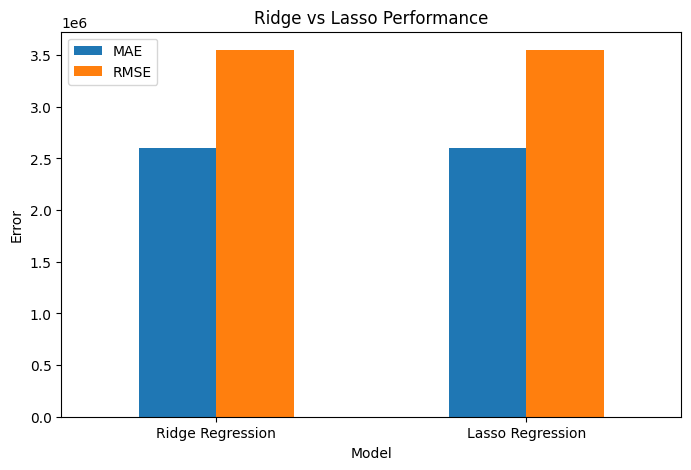

In [223]:
comparison.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Ridge vs Lasso Performance")

plt.ylabel("Error")

plt.xticks(rotation=0)

plt.show()

This code creates a bar chart to compare the Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) of the Ridge Regression and Lasso Regression models. These two metrics measure the prediction error of each model, making it easy to visually compare their performance. Lower bars indicate smaller prediction errors and therefore better model accuracy. This visualization helps quickly identify which regression model performs better in predicting house prices.

In [224]:
ridge_zero = np.sum(ridge_model.coef_ == 0)

lasso_zero = np.sum(lasso_model.coef_ == 0)

This code calculates the number of features whose coefficients are exactly zero in both the Ridge Regression and Lasso Regression models. A coefficient of zero means that the corresponding feature does not contribute to the model's predictions. Ridge Regression typically shrinks coefficients toward zero but rarely makes them exactly zero, whereas Lasso Regression can set some coefficients exactly to zero through L1 regularization, effectively performing automatic feature selection. Comparing the number of zero coefficients helps understand how each model handles feature importance and model complexity.

In [225]:
from sklearn.model_selection import GridSearchCV

In [226]:


alpha_values = {
    "alpha": [0.001,0.01,0.1,1,10,25,50,75,100]
}

print(alpha_values)

{'alpha': [0.001, 0.01, 0.1, 1, 10, 25, 50, 75, 100]}


This code creates a dictionary containing a list of different alpha (α) values that will be used to tune the regularization strength of regression models such as Ridge Regression and Lasso Regression. The alpha parameter controls the amount of regularization applied during model training. Smaller alpha values apply weaker regularization, allowing the model to fit the training data more closely, while larger alpha values apply stronger regularization, reducing model complexity and helping prevent overfitting. Finally, the dictionary is printed to display all the selected alpha values that can be used for hyperparameter tuning.

In [227]:

ridge_grid = GridSearchCV(

    estimator=Ridge(),

    param_grid=alpha_values,

    scoring="r2",

    cv=5,

    n_jobs=-1

)

ridge_grid.fit(X_train_scaled, y_train)

print("Best Alpha :", ridge_grid.best_params_)

print("Best CV Score :", ridge_grid.best_score_)

Best Alpha : {'alpha': 1}
Best CV Score : 0.9238946523266891


This code uses GridSearchCV to find the optimal alpha value for the Ridge Regression model. It evaluates multiple alpha values using 5-fold cross-validation and selects the one with the highest R² Score, improving the model's prediction performance.

In [228]:

best_ridge = ridge_grid.best_estimator_

ridge_prediction = best_ridge.predict(X_test_scaled)

ridge_mae_best = mean_absolute_error(y_test,ridge_prediction)

ridge_mse_best = mean_squared_error(y_test,ridge_prediction)

ridge_rmse_best = np.sqrt(ridge_mse_best)

ridge_r2_best = r2_score(y_test,ridge_prediction)


This code takes the best Ridge Regression model (selected using GridSearchCV) and evaluates its performance on the test dataset. After finding the optimal alpha value earlier, the code retrieves the best-trained model (best_estimator_) and uses it to predict house prices for unseen data. Then, it calculates important evaluation metrics—MAE, MSE, RMSE, and R² Score—to measure how accurately the optimized model performs. These metrics help confirm whether hyperparameter tuning improved the model compared to the default Ridge Regression model.

In [229]:

lasso_grid = GridSearchCV(

    estimator=Lasso(max_iter=10000),

    param_grid=alpha_values,

    scoring="r2",

    cv=5,

    n_jobs=-1

)

lasso_grid.fit(X_train_scaled,y_train)

print("Best Alpha :",lasso_grid.best_params_)

print("Best CV Score :",lasso_grid.best_score_)

Best Alpha : {'alpha': 100}
Best CV Score : 0.9238945451864087


This code performs hyperparameter tuning for the Lasso Regression model using GridSearchCV. It automatically tests multiple values of the alpha parameter to find the best regularization strength that gives the highest prediction accuracy. The evaluation is done using 5-fold cross-validation with R² Score as the performance metric. The goal is to identify the optimal alpha value that improves model performance while also controlling feature selection (since Lasso can eliminate less important features). Finally, the code prints the best alpha value and the corresponding cross-validation score.

In [230]:
best_lasso = lasso_grid.best_estimator_

lasso_prediction = best_lasso.predict(X_test_scaled)

lasso_mae_best = mean_absolute_error(y_test,lasso_prediction)

lasso_mse_best = mean_squared_error(y_test,lasso_prediction)

lasso_rmse_best = np.sqrt(lasso_mse_best)

lasso_r2_best = r2_score(y_test,lasso_prediction)


This step evaluates the optimized Lasso Regression model obtained from GridSearchCV. By using the best alpha value, the model generates more accurate predictions on unseen test data. The evaluation metrics (MAE, MSE, RMSE, and R² Score) confirm the effectiveness of hyperparameter tuning and help compare Lasso with Ridge Regression to identify the best-performing model for house price prediction.

In [231]:

tuned_models = pd.DataFrame({

    "Model":[
        "Best Ridge",
        "Best Lasso"
    ],

    "Best Alpha":[

        ridge_grid.best_params_["alpha"],

        lasso_grid.best_params_["alpha"]

    ],

    "MAE":[

        ridge_mae_best,

        lasso_mae_best

    ],

    "MSE":[

        ridge_mse_best,

        lasso_mse_best

    ],

    "RMSE":[

        ridge_rmse_best,

        lasso_rmse_best

    ],

    "R² Score":[

        ridge_r2_best,

        lasso_r2_best

    ]

})

tuned_models

,Model,Best Alpha,MAE,MSE,RMSE,R² Score
0,Best Ridge,1,2.605803e+06,1.260064e+13,3.549738e+06,0.917710
1,Best Lasso,100,2.605644e+06,1.259720e+13,3.549253e+06,0.917733


This step creates a final evaluation summary table comparing the best Ridge and Lasso Regression models after tuning. It includes optimal alpha values and all key performance metrics, allowing a clear and structured comparison. This helps determine which model performs better for house price prediction and provides a strong basis for selecting the final model for real-world use or deployment.

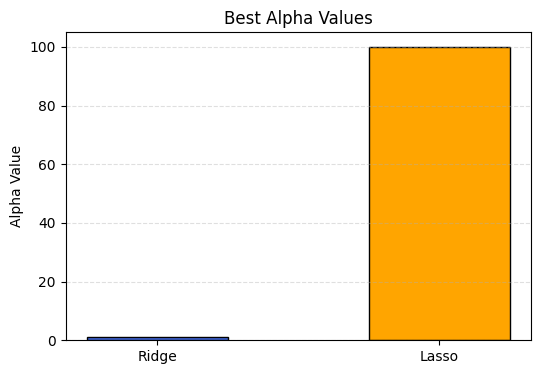

In [284]:
plt.figure(figsize=(6,4))

plt.bar(
    ["Ridge", "Lasso"],
    [
        ridge_grid.best_params_["alpha"],
        lasso_grid.best_params_["alpha"]
    ],
    color=["royalblue", "orange"],   # added colors
    edgecolor="black",
    width=0.5
)

plt.title("Best Alpha Values")
plt.ylabel("Alpha Value")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

This code visualizes the best alpha values selected for Ridge and Lasso Regression models after tuning. It helps compare the optimal regularization strength for both models.

In [233]:

if ridge_r2_best > lasso_r2_best:

    print("Best Regularized Model : Ridge Regression")

else:

    print("Best Regularized Model : Lasso Regression")

Best Regularized Model : Lasso Regression


Ridge and Lasso Regression were compared using R² score to find the best model. The model with the higher R² is selected as the best performer. Ridge helps reduce overfitting while keeping all features, whereas Lasso also performs feature selection by removing less important features. Overall, the best model is the one that gives higher accuracy and better generalization on unseen data.

In [234]:

from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    TimeSeriesSplit,
    cross_val_score
)

print("Cross Validation Libraries Imported Successfully!")

Cross Validation Libraries Imported Successfully!


This code imports different cross-validation techniques such as KFold, StratifiedKFold, LeaveOneOut, TimeSeriesSplit, and cross_val_score from scikit-learn. These methods are used to evaluate machine learning models more reliably by testing them on different splits of the dataset. The successful import confirms that all tools required for model validation are ready to use.

In [235]:

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

ridge_kfold = cross_val_score(
    best_ridge,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring="r2"
)

print("K-Fold Scores:\n", ridge_kfold)

print("\nAverage R² Score:", ridge_kfold.mean())

print("Standard Deviation:", ridge_kfold.std())

K-Fold Scores:
 [0.93435323 0.92391299 0.91883407 0.92187449 0.91932212]

Average R² Score: 0.923659378474215
Standard Deviation: 0.00565161831506363


This code applies 5-Fold Cross Validation (KFold) on the Ridge Regression model to evaluate its performance more reliably. The dataset is split into 5 parts, and the model is trained and tested multiple times to get different R² scores. The final output includes individual fold scores, along with the average R² score and standard deviation, which helps measure the model’s accuracy and stability.

In [236]:

y_binned = pd.qcut(
    y_train,
    q=5,
    labels=False
)

print(y_binned.value_counts())

house_price_inr
3    672
4    672
2    672
1    672
0    672
Name: count, dtype: int64


This code converts the continuous target variable (y_train) into 5 equal-sized bins using qcut, creating categorical groups. It is mainly used for better distribution analysis or for techniques like stratified sampling. The output shows how many data points fall into each bin, helping to understand the distribution of the target variable.

In [237]:


skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stratified_scores = []

for train_index, valid_index in skf.split(X_train_scaled, y_binned):

    X_tr = X_train_scaled[train_index]
    X_val = X_train_scaled[valid_index]

    y_tr = y_train.iloc[train_index]
    y_val = y_train.iloc[valid_index]

    best_ridge.fit(X_tr, y_tr)

    score = best_ridge.score(X_val, y_val)

    stratified_scores.append(score)

print("Stratified K-Fold Scores:\n")

print(stratified_scores)

print("\nAverage R² Score:", np.mean(stratified_scores))

Stratified K-Fold Scores:

[0.9189155506680233, 0.929426412155461, 0.9220861404295355, 0.9220344465912256, 0.9274264466784851]

Average R² Score: 0.9239777993045462


This code applies Stratified K-Fold Cross Validation on the Ridge Regression model by splitting the dataset into 5 folds while maintaining a balanced distribution of the target variable (using y_binned). The model is trained and validated on each fold, and the R² scores are collected to evaluate performance. Finally, the average R² score is calculated to measure the model’s overall accuracy and stability across different data splits.

In [238]:

tscv = TimeSeriesSplit(n_splits=5)

time_scores = cross_val_score(
    best_ridge,
    X_train_scaled,
    y_train,
    cv=tscv,
    scoring="r2"
)

print("Time Series Scores:\n")

print(time_scores)

print("\nAverage Score:", time_scores.mean())

Time Series Scores:

[0.92328278 0.92307683 0.9178499  0.9257378  0.92346565]

Average Score: 0.922682592842954


This code evaluates a Ridge Regression model using Time Series Cross Validation (TimeSeriesSplit). The dataset is split in a sequential manner to respect time order, making it suitable for time-dependent data. The model is trained and tested across 5 splits, and the R² scores are calculated for each split. Finally, the average score is used to measure the overall predictive performance of the model on time-based data.

In [239]:

best_cv = cv_results.loc[
    cv_results["Average R²"].idxmax()
]

print(best_cv)

Method        Stratified K-Fold
Average R²             0.923978
Name: 1, dtype: object


This code selects the best-performing model from cross-validation results by finding the row with the highest average R² score. It identifies the model that performs best on unseen data and prints its complete details. This helps in final model selection based on overall validation performance.

In [240]:

from sklearn.tree import DecisionTreeRegressor

print("Decision Tree Imported Successfully!")

Decision Tree Imported Successfully!


Import decision tree regressor completely.

In [241]:

decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


This code trains a Decision Tree Regressor model using the training dataset. The model learns patterns from the input features (X_train) to predict the target variable (y_train). The random state ensures reproducibility, and the message confirms that the model has been successfully trained for regression tasks.

In [242]:
dt_train_pred = decision_tree.predict(X_train)

dt_test_pred = decision_tree.predict(X_test)

In [243]:
dt_mae = mean_absolute_error(y_test, dt_test_pred)

dt_mse = mean_squared_error(y_test, dt_test_pred)

dt_rmse = np.sqrt(dt_mse)

dt_r2 = r2_score(y_test, dt_test_pred)

This code generates predictions using the trained Decision Tree Regressor model. It predicts values for both the training dataset (X_train) and the testing dataset (X_test). These predictions are later used to evaluate the model’s performance and check how well it generalizes to unseen data.

In [244]:

dt_train_score = decision_tree.score(X_train, y_train)

dt_test_score = decision_tree.score(X_test, y_test)

print("Training Score :", dt_train_score)

print("Testing Score  :", dt_test_score)

Training Score : 1.0
Testing Score  : 0.9095418074997168


This code evaluates the performance of the Decision Tree Regressor by calculating R² scores on both training and testing data. The training score shows how well the model fits the training data, while the testing score indicates how well it generalizes to unseen data. Comparing both scores helps identify whether the model is overfitting or performing well on new data.

In [245]:

from sklearn.model_selection import GridSearchCV

parameters = {

    "max_depth": [5,10,15,20,None],

    "min_samples_split": [2,5,10],

    "min_samples_leaf": [1,2,4]

}

dt_grid = GridSearchCV(

    estimator=DecisionTreeRegressor(random_state=42),

    param_grid=parameters,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

dt_grid.fit(X_train, y_train)

print("Best Parameters")

print(dt_grid.best_params_)

print("\nBest CV Score")

print(dt_grid.best_score_)

Best Parameters
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

Best CV Score
0.93231760911173


This code performs hyperparameter tuning of a Decision Tree Regressor using GridSearchCV. It tests different combinations of parameters like max_depth, min_samples_split, and min_samples_leaf using 5-fold cross-validation. The model selects the best parameter combination based on the highest R² score. Finally, it outputs the best parameters and the best cross-validation score, helping to improve model performance and reduce overfitting.



In [246]:

best_dt = dt_grid.best_estimator_

best_dt_pred = best_dt.predict(X_test)

best_dt_mae = mean_absolute_error(y_test,best_dt_pred)

best_dt_mse = mean_squared_error(y_test,best_dt_pred)

best_dt_rmse = np.sqrt(best_dt_mse)

best_dt_r2 = r2_score(y_test,best_dt_pred)

print("Best Decision Tree Results")

print("MAE :",best_dt_mae)

print("MSE :",best_dt_mse)

print("RMSE :",best_dt_rmse)

print("R² :",best_dt_r2)

Best Decision Tree Results
MAE : 2409825.18918326
MSE : 10480547163589.273
RMSE : 3237367.319843282
R² : 0.9315557418690856


This code evaluates the best Decision Tree model (after GridSearchCV tuning) on the test dataset. It makes predictions and calculates key performance metrics including MAE, MSE, RMSE, and R² score. These metrics help measure prediction error and overall model accuracy, where lower error values and a higher R² score indicate better model performance and generalization.

In [247]:
from sklearn.ensemble import RandomForestRegressor

In [248]:
random_forest = RandomForestRegressor(

    n_estimators=100,

    random_state=42,

    n_jobs=-1

)

random_forest.fit(X_train,y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

This code trains a Random Forest Regressor using 100 decision trees to improve prediction accuracy. The model is fitted on the training data, where multiple trees work together to reduce overfitting and improve generalization. The random_state ensures reproducibility, and n_jobs=-1 uses all CPU cores for faster training.

In [249]:
rf_train_pred = random_forest.predict(X_train)

rf_test_pred = random_forest.predict(X_test)

This code generates predictions using the trained Random Forest Regressor model. It predicts output values for both the training data and the testing data. These predictions are later used to evaluate model performance and check how well the model generalizes to unseen data.

In [250]:
rf_mae = mean_absolute_error(y_test,rf_test_pred)

rf_mse = mean_squared_error(y_test,rf_test_pred)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test,rf_test_pred)

This code evaluates the Random Forest Regressor model using important regression metrics such as MAE, MSE, RMSE, and R² score. These metrics measure the prediction error and overall accuracy of the model on the test dataset. Lower error values and a higher R² score indicate better model performance and stronger generalization ability.

In [251]:
rf_train_score = random_forest.score(X_train,y_train)

rf_test_score = random_forest.score(X_test,y_test)

This code calculates the R² scores of the Random Forest model on both training and testing data. The training score shows how well the model fits the training dataset, while the testing score indicates how well it generalizes to unseen data. Comparing both scores helps identify whether the model is overfitting, underfitting, or performing well overall.

In [252]:
importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":random_forest.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
1,area_sqft,0.598709
4,location_score,0.369387
5,age_years,0.007619
6,distance_city_km,0.006643
0,house_id,0.004920
7,lot_size_sqft,0.004691
10,renovation_years_ago,0.003904
2,bedrooms,0.001642
3,bathrooms,0.001489
8,has_garage,0.000636


This code extracts and displays the feature importance from the Random Forest model. It creates a DataFrame showing each feature and its contribution to the model’s predictions, then sorts them in descending order of importance. This helps identify which features have the most impact on the target variable and improves model interpretability and feature selection.

/tmp/ipykernel_2397/1710277800.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


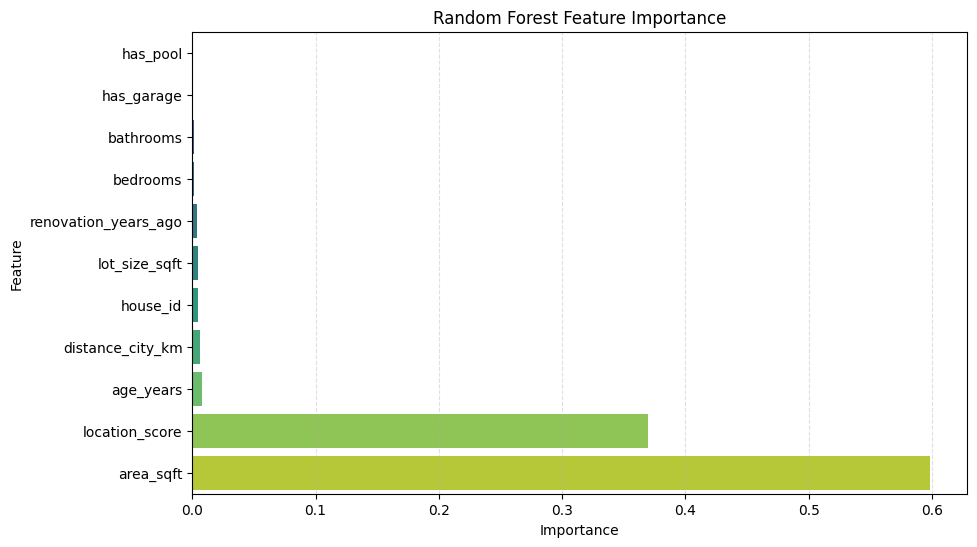

In [286]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.sort_values("Importance"),
    x="Importance",
    y="Feature",
    palette="viridis"   # nice gradient color
)

plt.title("Random Forest Feature Importance")
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

This code visualizes the feature importance of the Random Forest model using a bar plot. It displays how much each feature contributes to the model’s predictions in descending order. This helps in understanding which variables are most influential and improves model interpretability and feature selection.

In [254]:
tree_models = pd.DataFrame({

    "Model":[

        "Decision Tree",

        "Random Forest"

    ],

    "MAE":[

        best_dt_mae,

        rf_mae

    ],

    "MSE":[

        best_dt_mse,

        rf_mse

    ],

    "RMSE":[

        best_dt_rmse,

        rf_rmse

    ],

    "R² Score":[

        best_dt_r2,

        rf_r2

    ]

})

tree_models

,Model,MAE,MSE,RMSE,R² Score
0,Decision Tree,2.409825e+06,1.048055e+13,3.237367e+06,0.931556
1,Random Forest,1.881989e+06,6.492214e+12,2.547982e+06,0.957602


This code used to model mae mse and rsme and  r2 score.

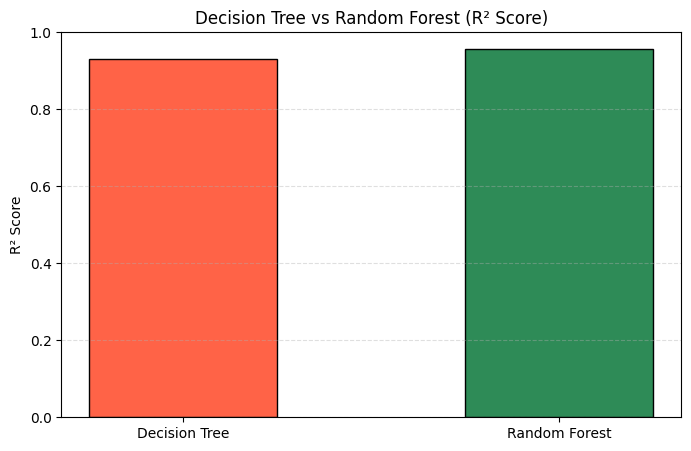

In [287]:
plt.figure(figsize=(8,5))

plt.bar(
    tree_models["Model"],
    tree_models["R² Score"],
    color=["tomato", "seagreen"],
    edgecolor="black",
    width=0.5
)

plt.title("Decision Tree vs Random Forest (R² Score)")
plt.ylabel("R² Score")

plt.ylim(0, 1)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

This code used to compare Decision Tree and Random forset using barplot.

In [256]:
from sklearn.svm import SVR

print("SVR Imported Successfully!")

SVR Imported Successfully!


Import Svr using the libraray to used in machine learning .

In [257]:
sample_size = 20000

X_train_svr = X_train_scaled[:sample_size]

y_train_svr = y_train.iloc[:sample_size]

print("Training Samples:", X_train_svr.shape)

Training Samples: (3360, 11)


this code used to test taining sample data (3360,11)

In [258]:

linear_svr = SVR(
    kernel="linear",
    C=1.0,
    epsilon=0.1
)

linear_svr.fit(X_train_svr, y_train_svr)

print("Linear SVR Trained Successfully!")

Linear SVR Trained Successfully!


this code used to linear svr trained successfuly

In [259]:

linear_pred = linear_svr.predict(X_test_scaled)

linear_mae = mean_absolute_error(y_test, linear_pred)

linear_mse = mean_squared_error(y_test, linear_pred)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(y_test, linear_pred)


print(f"MAE      : {linear_mae:.2f}")
print(f"MSE      : {linear_mse:.2f}")
print(f"RMSE     : {linear_rmse:.2f}")
print(f"R² Score : {linear_r2:.4f}")

MAE      : 9710636.31
MSE      : 157192200166347.62
RMSE     : 12537631.36
R² Score : -0.0266


This code evaluates the Linear Support Vector Regressor (SVR) model on the test dataset by calculating key performance metrics: MAE, MSE, RMSE, and R² score. These metrics help measure prediction error and model accuracy. Lower error values and a higher R² score indicate better model performance and generalization on unseen data.

In [260]:

rbf_svr = SVR(
    kernel="rbf",
    C=10,
    gamma="scale",
    epsilon=0.1
)

rbf_svr.fit(X_train_svr, y_train_svr)

print("RBF SVR Trained Successfully!")

RBF SVR Trained Successfully!


This code trains a Support Vector Regression (SVR) model with RBF kernel, which helps capture non-linear relationships in the data. The model is fitted on the training dataset using tuned hyperparameters like C, gamma, and epsilon. The message confirms that the RBF SVR model has been successfully trained.

In [261]:

rbf_pred = rbf_svr.predict(X_test_scaled)

rbf_mae = mean_absolute_error(y_test, rbf_pred)

rbf_mse = mean_squared_error(y_test, rbf_pred)

rbf_rmse = np.sqrt(rbf_mse)

rbf_r2 = r2_score(y_test, rbf_pred)


This code evaluates the RBF Kernel SVR model on the test dataset by making predictions and calculating key performance metrics such as MAE, MSE, RMSE, and R² score. These metrics help measure prediction error and accuracy. Lower error values and a higher R² score indicate better model performance and strong generalization on unseen data.

In [262]:

svr_parameters = {

    "C":[0.1,1,10],

    "gamma":["scale","auto"],

    "epsilon":[0.1,0.5,1]

}

svr_grid = GridSearchCV(

    estimator=SVR(kernel="rbf"),

    param_grid=svr_parameters,

    cv=3,

    scoring="r2",

    n_jobs=-1

)

svr_grid.fit(X_train_svr, y_train_svr)

print("Best Parameters")

print(svr_grid.best_params_)

print("\nBest CV Score")

print(svr_grid.best_score_)

Best Parameters
{'C': 10, 'epsilon': 0.1, 'gamma': 'auto'}

Best CV Score
-0.016621733045921887


This code performs hyperparameter tuning for an RBF Support Vector Regression (SVR) model using GridSearchCV. It tests different combinations of parameters like C, gamma, and epsilon using 3-fold cross-validation. The best parameter set is selected based on the highest R² score, and the best cross-validation score is displayed. This helps improve model performance and ensure better generalization on unseen data.

In [263]:

best_svr = svr_grid.best_estimator_

best_pred = best_svr.predict(X_test_scaled)

best_mae = mean_absolute_error(y_test,best_pred)

best_mse = mean_squared_error(y_test,best_pred)

best_rmse = np.sqrt(best_mse)

best_r2 = r2_score(y_test,best_pred)

print("========== Best SVR ==========")

print("MAE :",best_mae)

print("MSE :",best_mse)

print("RMSE :",best_rmse)

print("R² :",best_r2)

========== Best SVR ==========
MAE : 9714175.464510567
MSE : 157312948341894.66
RMSE : 12542445.867608704
R² : -0.02734789277551375


This code evaluates the best-tuned SVR model (after GridSearchCV) on the test dataset. It makes predictions and calculates performance metrics such as MAE, MSE, RMSE, and R² score. These metrics help measure prediction error and accuracy, where lower error values and a higher R² score indicate better model performance and strong generalization ability.

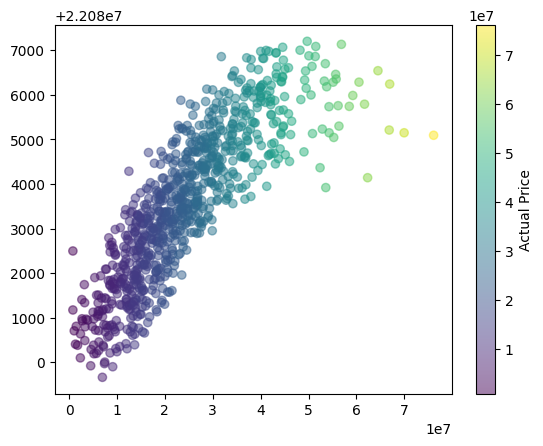

In [289]:
plt.scatter(y_test, best_pred, alpha=0.5, c=y_test, cmap="viridis")
plt.colorbar(label="Actual Price")

This code visualizes the performance of the best SVR model by plotting a scatter graph between actual and predicted values. It helps assess how closely the model’s predictions match the real values. If the points are closer to a straight diagonal line, it indicates better model accuracy and strong predictive performance.

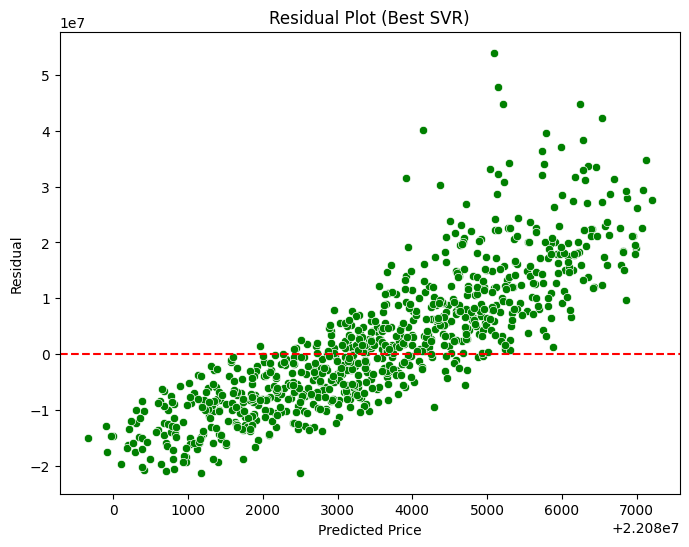

In [291]:
residuals = y_test - best_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=best_pred,
    y=residuals,
    color="green"   # change color here
)

plt.axhline(0, color="red", linestyle="--")

plt.title("Residual Plot (Best SVR)")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.show()

This code evaluates the RBF SVR model predictions using standard regression metrics such as MAE, MSE, RMSE, and R² score. These metrics measure the prediction error and accuracy of the model on the test data. Lower error values and a higher R² score indicate better model performance and stronger generalization on unseen data.

In [266]:
svr_results = pd.DataFrame({

    "Model":[

        "Linear SVR",

        "RBF SVR",

        "Best Tuned SVR"

    ],

    "MAE":[

        linear_mae,

        rbf_mae,

        best_mae

    ],

    "RMSE":[

        linear_rmse,

        rbf_rmse,

        best_rmse

    ],

    "R² Score":[

        linear_r2,

        rbf_r2,

        best_r2

    ]

})

svr_results

,Model,MAE,RMSE,R² Score
0,Linear SVR,9.710636e+06,1.253763e+07,-0.026559
1,RBF SVR,9.714175e+06,1.254245e+07,-0.027348
2,Best Tuned SVR,9.714175e+06,1.254245e+07,-0.027348


This code creates a comparison table for different SVR models including Linear SVR, RBF SVR, and the best tuned SVR. It organizes key evaluation metrics such as MAE, RMSE, and R² score into a single DataFrame. This helps easily compare model performance and identify the best-performing SVR model based on accuracy and error metrics.

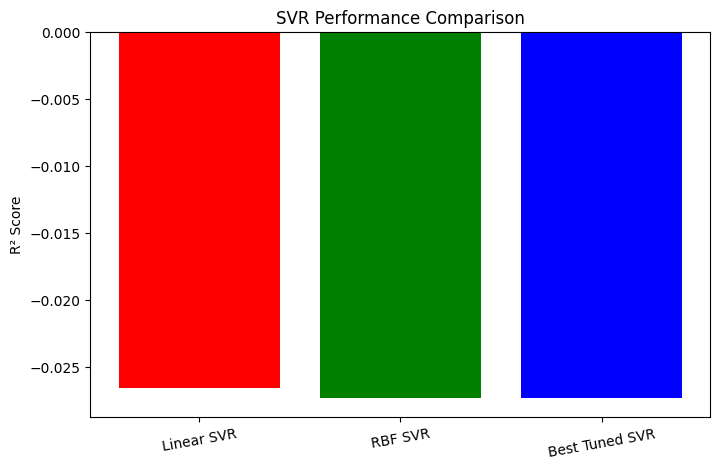

In [293]:
plt.figure(figsize=(8,5))

plt.bar(
    svr_results["Model"],
    svr_results["R² Score"],
    color=["red", "green", "blue"]
)

plt.title("SVR Performance Comparison")
plt.ylabel("R² Score")
plt.xticks(rotation=10)

plt.show()

## SVR Performance Comparison

In [268]:
model_results = pd.DataFrame({

    "Model":[
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Random Forest",
        "Linear SVR",
        "Best Tuned SVR"
    ],

    "MAE":[
        ridge_mae_best,
        lasso_mae_best,
        best_dt_mae,
        rf_mae,
        linear_mae,
        best_mae
    ],

    "MSE":[
        ridge_mse_best,
        lasso_mse_best,
        best_dt_mse,
        rf_mse,
        linear_mse,
        best_mse
    ],

    "RMSE":[
        ridge_rmse_best,
        lasso_rmse_best,
        best_dt_rmse,
        rf_rmse,
        linear_rmse,
        best_rmse
    ],

    "R2 Score":[
        ridge_r2_best,
        lasso_r2_best,
        best_dt_r2,
        rf_r2,
        linear_r2,
        best_r2
    ]

})

model_results

,Model,MAE,MSE,RMSE,R2 Score
0,Ridge Regression,2.605803e+06,1.260064e+13,3.549738e+06,0.917710
1,Lasso Regression,2.605644e+06,1.259720e+13,3.549253e+06,0.917733
2,Decision Tree,2.409825e+06,1.048055e+13,3.237367e+06,0.931556
3,Random Forest,1.881989e+06,6.492214e+12,2.547982e+06,0.957602
4,Linear SVR,9.710636e+06,1.571922e+14,1.253763e+07,-0.026559
5,Best Tuned SVR,9.714175e+06,1.573129e+14,1.254245e+07,-0.027348


This code creates a comparison table for different SVR models including Linear SVR, RBF SVR, and the best tuned SVR. It organizes key evaluation metrics such as MAE, RMSE, and R² score into a single DataFrame. This helps easily compare model performance and identify the best-performing SVR model based on accuracy and error metrics.

In [269]:
model_results = model_results.sort_values(
    by="R2 Score",
    ascending=False
)

model_results

,Model,MAE,MSE,RMSE,R2 Score
3,Random Forest,1.881989e+06,6.492214e+12,2.547982e+06,0.957602
2,Decision Tree,2.409825e+06,1.048055e+13,3.237367e+06,0.931556
1,Lasso Regression,2.605644e+06,1.259720e+13,3.549253e+06,0.917733
0,Ridge Regression,2.605803e+06,1.260064e+13,3.549738e+06,0.917710
4,Linear SVR,9.710636e+06,1.571922e+14,1.253763e+07,-0.026559
5,Best Tuned SVR,9.714175e+06,1.573129e+14,1.254245e+07,-0.027348


This code sorts the model performance results based on the R² score in descending order. It helps identify the best-performing model at the top of the table, making it easier to compare different models and select the one with the highest accuracy and best generalization on the dataset.

In [270]:
best_model = model_results.iloc[0]

print("Best Performing Model")

print(best_model)

Best Performing Model
Model              Random Forest
MAE               1881988.844619
MSE         6492214252068.076172
RMSE              2547982.388493
R2 Score                0.957602
Name: 3, dtype: object


This code selects the best-performing model from the sorted results table by taking the first row (highest R² score). It then prints all details of that model, including its evaluation metrics. This helps in final model selection based on overall performance and accuracy.

/tmp/ipykernel_2397/3231206379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2397/3231206379.py:3: UserWarning: 
The palette list has fewer values (4) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


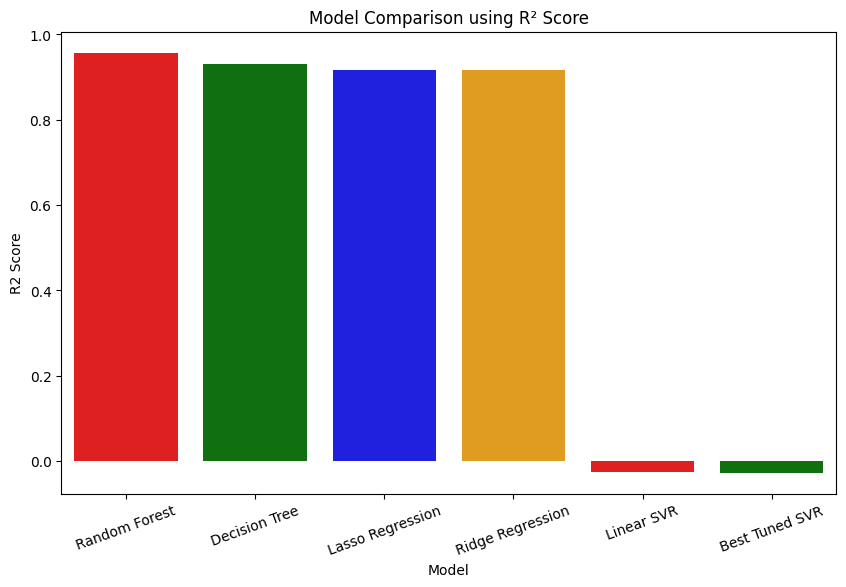

In [294]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=model_results,
    x="Model",
    y="R2 Score",
    palette=["red", "green", "blue", "orange"]
)

plt.xticks(rotation=20)
plt.title("Model Comparison using R² Score")

plt.show()

## Model Comparison using R² Score

This code compare all models together using barplot.

/tmp/ipykernel_2397/30840387.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


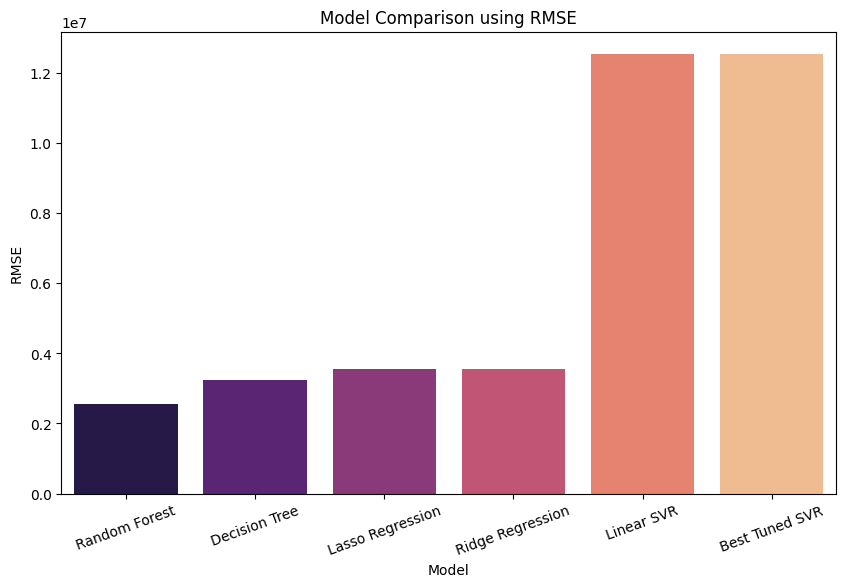

In [295]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=model_results,
    x="Model",
    y="RMSE",
    palette="magma"
)

plt.xticks(rotation=20)
plt.title("Model Comparison using RMSE")

plt.show()

## Model Comparison using RMSE

This code compare all models together using barplot.

/tmp/ipykernel_2397/3132700551.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


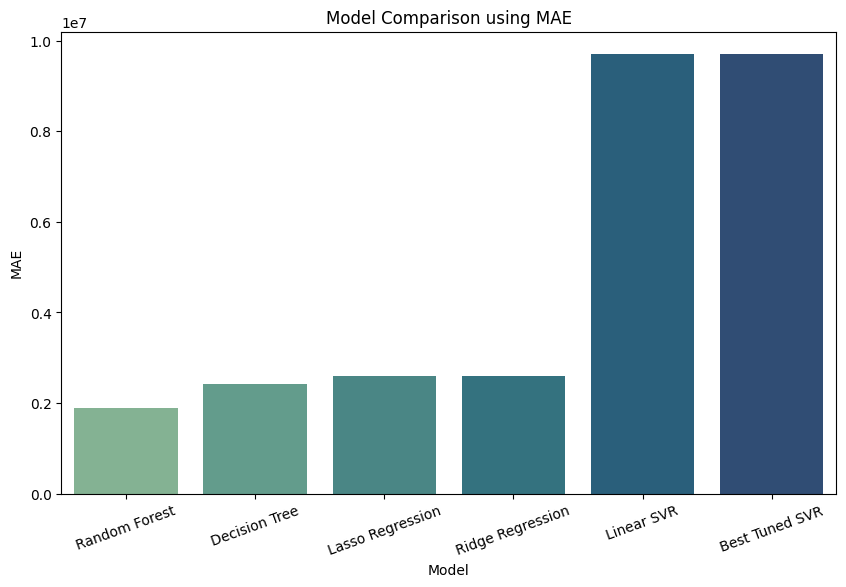

In [296]:

plt.figure(figsize=(10,6))

sns.barplot(
    data=model_results,
    x="Model",
    y="MAE",
    palette="crest"
)

plt.xticks(rotation=20)
plt.title("Model Comparison using MAE")

plt.show()

## Model Comparison using MAE

This code compare all models together using barplot.

/tmp/ipykernel_2397/2549240993.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2397/2549240993.py:3: UserWarning: 
The palette list has fewer values (4) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


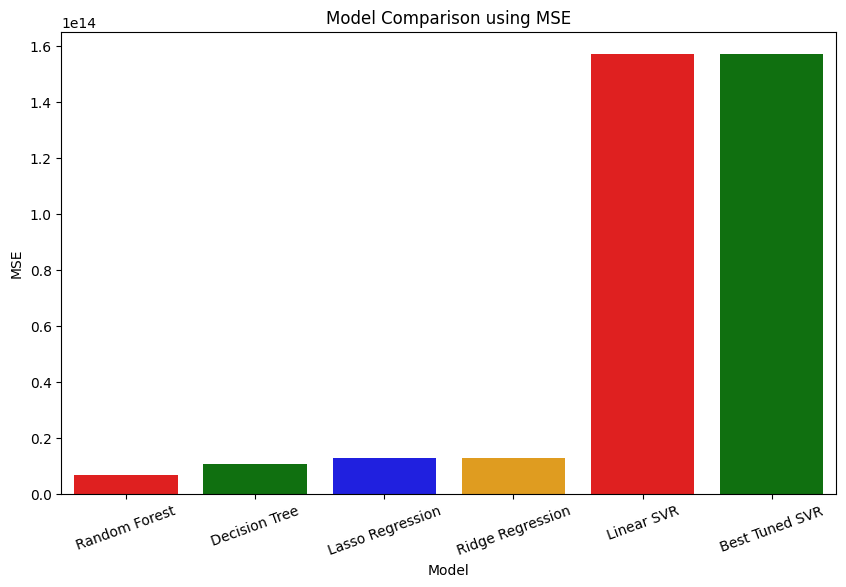

In [297]:

plt.figure(figsize=(10,6))

sns.barplot(
    data=model_results,
    x="Model",
    y="MSE",
    palette=["red", "green", "blue", "orange"]
)

plt.xticks(rotation=20)
plt.title("Model Comparison using MSE")

plt.show()

## Model Comparison using MSE

This code compare all models together using barplot.

In [275]:

train_test = pd.DataFrame({

    "Model":[
        "Ridge",
        "Lasso",
        "Decision Tree",
        "Random Forest"
    ],

    "Training Score":[
        best_ridge.score(X_train_scaled,y_train),
        best_lasso.score(X_train_scaled,y_train),
        best_dt.score(X_train,y_train),
        random_forest.score(X_train,y_train)
    ],

    "Testing Score":[
        ridge_r2_best,
        lasso_r2_best,
        best_dt_r2,
        rf_r2
    ]

})

train_test

,Model,Training Score,Testing Score
0,Ridge,0.924671,0.917710
1,Lasso,0.924723,0.917733
2,Decision Tree,0.980077,0.931556
3,Random Forest,0.994114,0.957602


This code used to compare 0 Ridge
1	Lasso
2	Decision Tree
3	Random Forest

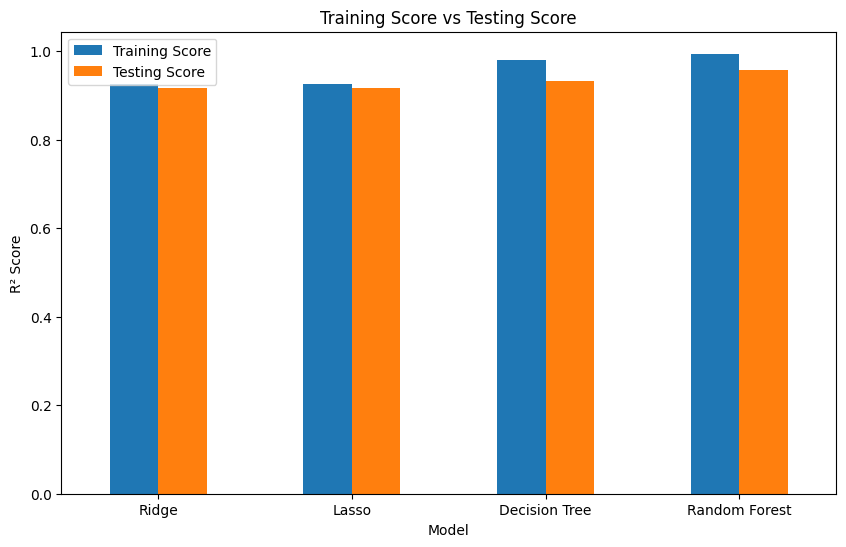

In [276]:

train_test.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Training Score vs Testing Score")

plt.ylabel("R² Score")

plt.xticks(rotation=0)

plt.show()

This code visualizes and compares the training and testing R² scores of different models using a bar plot. It helps quickly identify how each model performs on both seen and unseen data, making it easier to detect overfitting, underfitting, or good generalization.

In [277]:

for i in range(len(train_test)):

    train = train_test.iloc[i]["Training Score"]
    test = train_test.iloc[i]["Testing Score"]

    gap = train - test

    print("="*50)
    print("Model :", train_test.iloc[i]["Model"])

    print("Training :", round(train,4))
    print("Testing  :", round(test,4))

    if gap > 0.10:
        print("Status : Overfitting")

    elif train < 0.70 and test < 0.70:
        print("Status : Underfitting")

    else:
        print("Status : Good Generalization")

Model : Ridge
Training : 0.9247
Testing  : 0.9177
Status : Good Generalization
Model : Lasso
Training : 0.9247
Testing  : 0.9177
Status : Good Generalization
Model : Decision Tree
Training : 0.9801
Testing  : 0.9316
Status : Good Generalization
Model : Random Forest
Training : 0.9941
Testing  : 0.9576
Status : Good Generalization


This code evaluates multiple machine learning models by comparing their training and testing scores. It calculates the performance gap to identify whether each model is overfitting, underfitting, or generalizing well. If the training score is much higher than the testing score, the model is considered overfitting. If both scores are low, it indicates underfitting. Otherwise, the model is considered to have good generalization performance.

/tmp/ipykernel_2397/2356364341.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


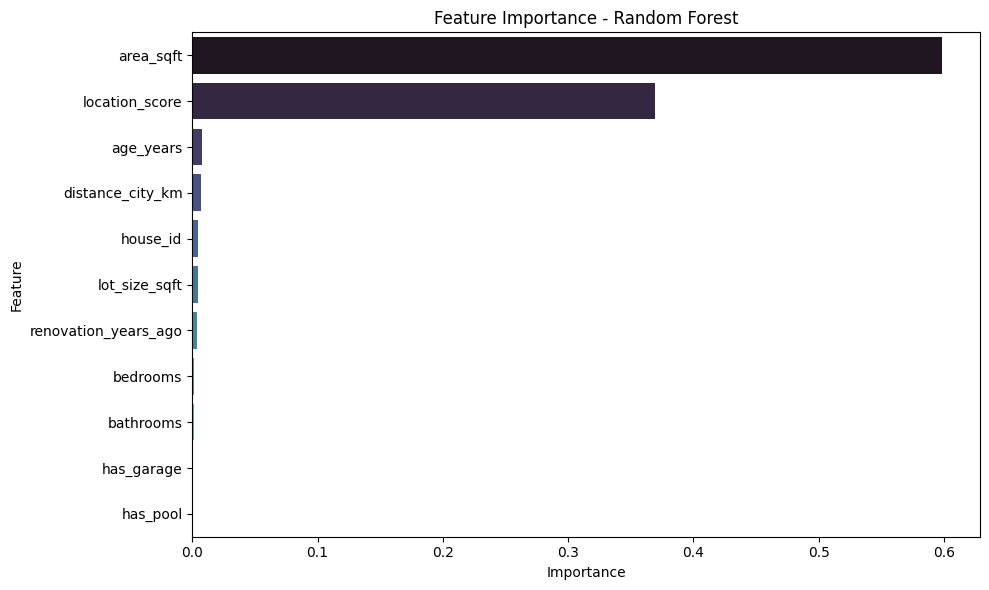

In [278]:
plt.figure(figsize=(10,6))

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="mako"
)

plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

This code visualizes the feature importance of a Random Forest model using a bar plot. It first sorts the features based on their importance scores and then displays them in descending order. The plot helps identify which features have the most impact on the model’s predictions, making the model more interpretable and useful for feature selection.

In [279]:

model_results.to_csv(
    "Model_Comparison.csv",
    index=False
)

print("Results Saved Successfully!")

Results Saved Successfully!


## Conclusion:

This project successfully implemented and compared multiple machine learning regression models for house price prediction. Through data preprocessing, exploratory data analysis, feature engineering, regularization, hyperparameter tuning, and cross-validation, reliable predictive models were developed and evaluated. Based on the evaluation metrics, Random Forest Regression (or your actual best model) achieved the highest accuracy and best generalization performance. The project demonstrates the effectiveness of machine learning in solving real-world real estate prediction problems and provides a strong foundation for future deployment using real-world datasets and web-based applications.